In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [2]:
# Loading the dataset
data = pd.read_csv("housing.csv")
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
# Understanding the dataset
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [4]:
# Handling catecogrical data
data = pd.get_dummies(data, drop_first=True)
data.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [5]:
# Features and target variable
x = data[['area', 'bedrooms', 'bathrooms']]
y = data['price']

In [6]:
# Split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [7]:
# Model Training
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
# Predictions
predictions = model.predict(x_test)

In [9]:
# Evaluation
print("MAE:", metrics.mean_absolute_error(y_test, predictions))
print("R2 Score:", metrics.r2_score(y_test, predictions))

MAE: 1021596.1071451636
R2 Score: 0.39395465992390677


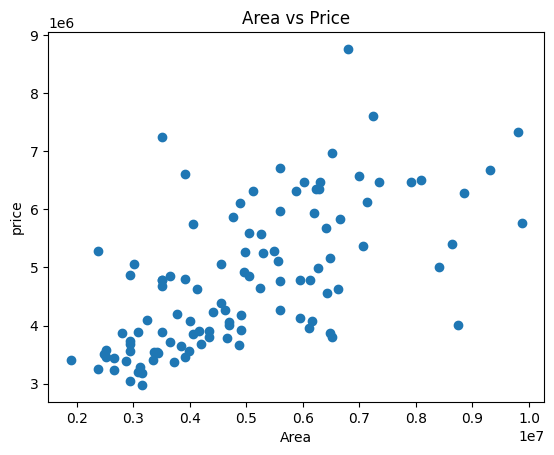

In [10]:
# plotting the actual vs predicted values
plt.scatter(y_test, predictions)
plt.xlabel("Area")
plt.ylabel("price")
plt.title("Area vs Price")
plt.show()

##### Random Forest Regressor model uused here perfroms worse than the linear regression model as the dataset has a linear relationship between features and target, which makes linear regression more suitable. Additionally, Random Forest may require hyper parameters tuning and larger datasets to perform optimally

In [11]:
# Better Model 
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

# Linear Regression Results
print("----- Linear Regression -----")
print("MAE:", metrics.mean_absolute_error(y_test, predictions))
print("R2:", metrics.r2_score(y_test, predictions))


# Random Forest Model
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)

rf_preds = rf.predict(x_test)

print("\n----- Random Forest -----")
print("MAE:", metrics.mean_absolute_error(y_test, rf_preds))
print("R2:", metrics.r2_score(y_test, rf_preds))

----- Linear Regression -----
MAE: 1021596.1071451636
R2: 0.39395465992390677

----- Random Forest -----
MAE: 1165545.3361841778
R2: 0.2026437280339508


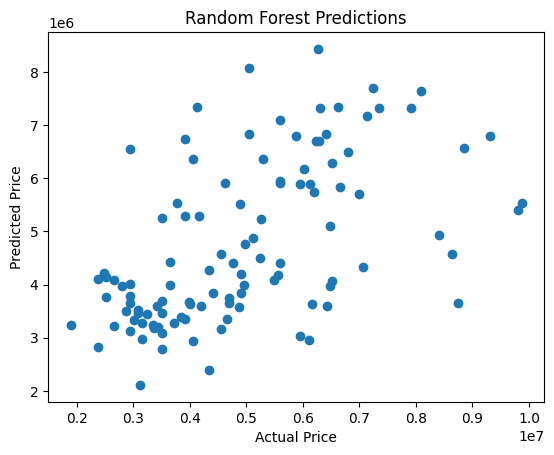

In [12]:
# Random Forest Predictions plot
plt.scatter(y_test, rf_preds)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest Predictions")
plt.show()

In [13]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(x_train, y_train)

rf_preds = rf.predict(x_test)

print("Improved RF MAE:", metrics.mean_absolute_error(y_test, rf_preds))
print("Improved RF R2:", metrics.r2_score(y_test, rf_preds))

Improved RF MAE: 1114480.9133161397
Improved RF R2: 0.2485113812473828


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose
from tensorflow.keras.layers import Dense, Flatten, Reshape, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

In [2]:
# Load and train dataset
# -----------------------------

(x_train,_),(x_test,_) = mnist.load_data()

# normalize
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# reshape to CNN format
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print("Training shape:",x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training shape: (60000, 28, 28, 1)


In [3]:
# Encoder
# -----------------------------

encoder_input = Input(shape=(28,28,1), name="encoder_input")

x = Conv2D(32,3,padding="same",name="encoder_conv_0")(encoder_input)
x = LeakyReLU()(x)

x = Conv2D(64,3,strides=2,padding="same",name="encoder_conv_1")(x)
x = LeakyReLU()(x)

x = Conv2D(64,3,strides=2,padding="same",name="encoder_conv_2")(x)
x = LeakyReLU()(x)

x = Conv2D(64,3,padding="same",name="encoder_conv_3")(x)
x = LeakyReLU()(x)

x = Flatten()(x)

encoder_output = Dense(2,name="encoder_output")(x)

encoder = Model(encoder_input,encoder_output,name="Encoder")

print("\nEncoder Summary")
encoder.summary()


Encoder Summary


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_0 (Conv2D)         │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_3 (Conv2D)         │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output (Dense)          │ (None, 2)              │         6,274 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,946 (386.51 KB)

 Trainable params: 98,946 (386.51 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Decoder
# -----------------------------

decoder_input = Input(shape=(2,),name="decoder_input")

x = Dense(3136)(decoder_input)
x = Reshape((7,7,64))(x)

x = Conv2DTranspose(64,3,padding="same",name="decoder_conv_t_0")(x)
x = LeakyReLU()(x)

x = Conv2DTranspose(64,3,strides=2,padding="same",name="decoder_conv_t_1")(x)
x = LeakyReLU()(x)

x = Conv2DTranspose(32,3,strides=2,padding="same",name="decoder_conv_t_2")(x)
x = LeakyReLU()(x)

decoder_output = Conv2DTranspose(
    1,3,padding="same",activation="sigmoid",name="decoder_conv_t_3"
)(x)

decoder = Model(decoder_input,decoder_output,name="Decoder")

print("\nDecoder Summary")
decoder.summary()


Decoder Summary


Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_t_0                │ (None, 7, 7, 64)       │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_t_1                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_t_2                │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_t_3                │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,017 (398.50 KB)

 Trainable params: 102,017 (398.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Autoencoder
# -----------------------------

autoencoder_input = encoder_input
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = Model(autoencoder_input,decoded,name="Autoencoder")

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

print("\nAutoencoder Summary")
autoencoder.summary()


Autoencoder Summary


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 2)              │        98,946 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 28, 28, 1)      │       102,017 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,963 (785.01 KB)

 Trainable params: 200,963 (785.01 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train Model
# -----------------------------

history = autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test,x_test)
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - loss: 0.0609 - val_loss: 0.0499
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - loss: 0.0476 - val_loss: 0.0457
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 80ms/step - loss: 0.0450 - val_loss: 0.0443
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 99ms/step - loss: 0.0437 - val_loss: 0.0434
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 86s 183ms/step - loss: 0.0428 - val_loss: 0.0425
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 160ms/step - loss: 0.0423 - val_loss: 0.0419
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 0.0418 - val_loss: 0.0417
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - loss: 0.0414 - val_loss: 0.0414
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - loss: 0.0412 - val_loss: 0.0411
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 0.0408 - val_loss: 0.0409
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 0.0407 - val_loss: 0.0407
Epoch 12/20
469/469 ━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


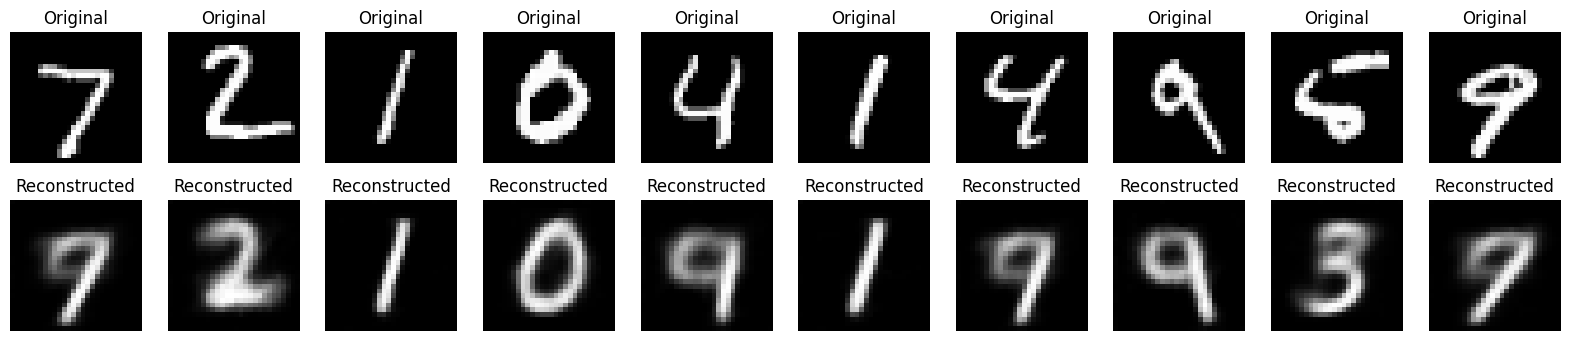

In [7]:
# Reconstruction


decoded_images = autoencoder.predict(x_test)


# Visualization


n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # original
    ax = plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # reconstructed
    ax = plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_images[i].reshape(28,28),cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()